Описание набора данных:

- school_id : идентификатор школы для каждого ученика 

- state_code - уникальный идентификатор для каждого штата 

- subjects - сгенерированные через пробел названия предметов, все в нижнем регистре

In [3]:
# Импортируем библиотеку и загружаем файл ля работы
import pandas as pd

School_df = pd.read_excel("school_data.xlsx", index_col="school_id")
School_df

,state_code,subjects
school_id,,
sch_1,!@sc_1,english maths chemistry
sch_2,))sc_2,english physics chemistry
sch_3,!@sc_2,maths biology
sch_4,sc_2)_,french physics social_studies
sch_5,sc_3#@,social_studies maths literature
sch_11,sc4,english physics chemistry
sch_21,))sc_2,english physics chemistry
sch_6,!@sc_2,maths biology
sch_14,sc_2)_,french maths english physics


##### 1. Удалите все школы, предлагающие менее 3 предметов.

In [4]:
School_df = School_df[School_df['subjects'].str.split().str.len() >= 3]
School_df

,state_code,subjects
school_id,,
sch_1,!@sc_1,english maths chemistry
sch_2,))sc_2,english physics chemistry
sch_4,sc_2)_,french physics social_studies
sch_5,sc_3#@,social_studies maths literature
sch_11,sc4,english physics chemistry
sch_21,))sc_2,english physics chemistry
sch_14,sc_2)_,french maths english physics
sch_8,sc_4#@,social_studies maths literature


##### 2. Очистите столбец "state_code" так, чтобы он содержал только буквенно-цифровые символы.

In [5]:
# Чистим данные и приводим в читабельный вид
import re

School_df["state_code"] = School_df["state_code"].apply(lambda x: re.sub("[!@()#\\s_]", '', str(x)))
School_df

,state_code,subjects
school_id,,
sch_1,sc1,english maths chemistry
sch_2,sc2,english physics chemistry
sch_4,sc2,french physics social_studies
sch_5,sc3,social_studies maths literature
sch_11,sc4,english physics chemistry
sch_21,sc2,english physics chemistry
sch_14,sc2,french maths english physics
sch_8,sc4,social_studies maths literature


##### 3. Для каждого штата верните количество школ, предлагающих английский язык, математику, физику и химию (English, Maths, Physics, Chemistry), каждую в отдельном столбце.

In [12]:
#Вывожу количество школ соответствующих поставленному условию для каждого штата
School_df["English"] = School_df["subjects"].str.contains("english").astype(int)
School_df["Maths"] = School_df["subjects"].str.contains("maths").astype(int)
School_df["Physics"] = School_df["subjects"].str.contains("physics").astype(int)
School_df["Chemistry"] = School_df["subjects"].str.contains("chemistry").astype(int)
School_df

,state_code,subjects,English,Maths,Physics,Chemistry
school_id,,,,,,
sch_1,sc1,english maths chemistry,1,1,0,1
sch_2,sc2,english physics chemistry,1,0,1,1
sch_4,sc2,french physics social_studies,0,0,1,0
sch_5,sc3,social_studies maths literature,0,1,0,0
sch_11,sc4,english physics chemistry,1,0,1,1
sch_21,sc2,english physics chemistry,1,0,1,1
sch_14,sc2,french maths english physics,1,1,1,0
sch_8,sc4,social_studies maths literature,0,1,0,0


In [15]:
#Вывожу фильнальную таблицу с результатом

final_table = School_df.groupby('state_code')[["English", "Maths", "Physics", "Chemistry"]].sum()
final_table

,English,Maths,Physics,Chemistry
state_code,,,,
sc1,1,1,0,1
sc2,3,1,4,2
sc3,0,1,0,0
sc4,1,1,1,1


In [13]:
#Импортируем библиотеку для визуализации
import matplotlib.pyplot as plt

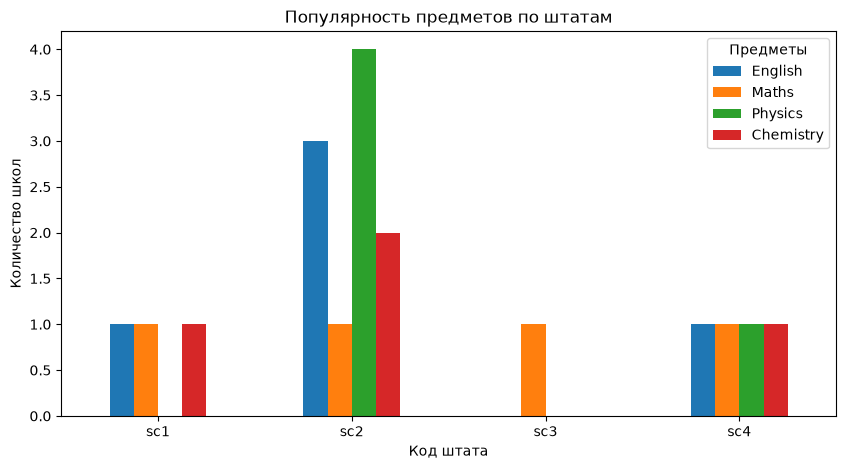

In [16]:
#Строим график
final_table.plot(kind = 'bar', figsize = (10,5))
plt.title('Популярность предметов по штатам')
plt.xlabel('Код штата')
plt.ylabel('Количество школ')
plt.legend(title='Предметы')
plt.xticks(rotation=0)
plt.show()